In [1]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [14]:
import pandas as pd
messages = pd.read_csv('Lab 30 spam.csv', sep=',', skiprows=1, names=['label', 'message'], engine='python')
messages.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
import pandas as pd
messages = pd.read_csv('Lab 30 spam.csv')
messages.columns = ['label', 'message']
messages.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
messages = [line.strip() for line in open('Lab 30 spam.csv')]
print(len(messages))

5575


In [12]:
for message_no, message in enumerate(messages[:10]):
    print(message_no, message)
    print('\n')

0 Category,Message


1 ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."


2 ham,Ok lar... Joking wif u oni...


3 spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


4 ham,U dun say so early hor... U c already then say...


5 ham,"Nah I don't think he goes to usf, he lives around here though"


6 spam,"FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv"


7 ham,Even my brother is not like to speak with me. They treat me like aids patent.


8 ham,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune


9 spam,WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim ca

In [21]:
import pandas as pd
messages = pd.read_csv('Lab 30 spam.csv', sep=',', skiprows=1, names=['label', 'message'], engine='python')
messages.describe()

,label,message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


In [22]:
# adding new col length
messages['length'] = messages['message'].apply(len)
messages.head()

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


<Axes: ylabel='Frequency'>

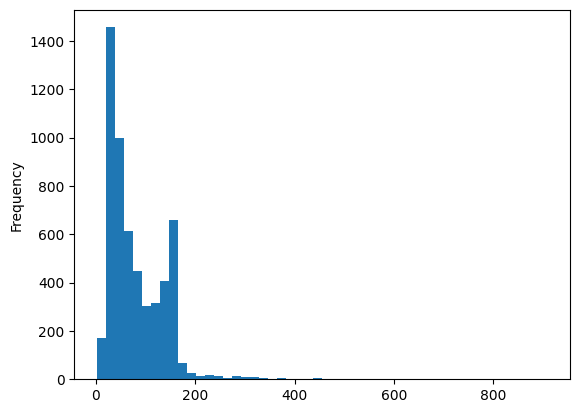

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

messages.length.plot(bins = 50, kind = 'hist')

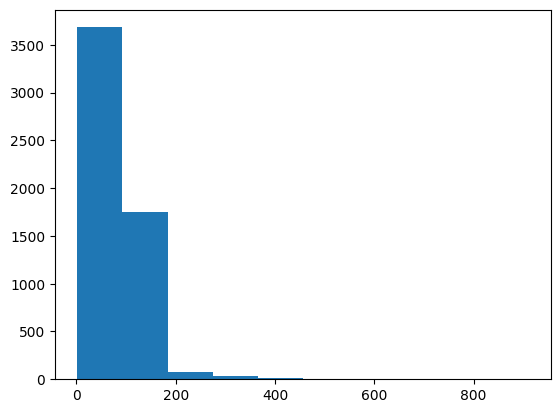

In [24]:
plt.hist(messages['length'])
plt.show()

In [26]:
import string
import nltk
msg = 'Hey this is Faculty of CSE!, Im learning AI on cloud platform'

nltk.download('punkt_tab') # Download the missing resource
from nltk.tokenize import word_tokenize
word_tokenize(msg)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['Hey',
 'this',
 'is',
 'Faculty',
 'of',
 'CSE',
 '!',
 ',',
 'Im',
 'learning',
 'AI',
 'on',
 'cloud',
 'platform']

In [29]:
# NLP - Stopwords removing - Text preprocessing
from nltk.corpus import stopwords


In [33]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords.words('english') [:10]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [36]:
stopwords.words('english') [:10]

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [35]:
nopunc = [char for char in msg if char not in string.punctuation]
nopunc = ''.join(nopunc)
msg

'Hey this is Faculty of CSE!, Im learning AI on cloud platform'

In [37]:
nopunc

'Hey this is Faculty of CSE Im learning AI on cloud platform'

In [38]:
from nltk.corpus import stopwords
cl_msg = [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]
cl_msg

['Hey', 'Faculty', 'CSE', 'Im', 'learning', 'AI', 'cloud', 'platform']

In [41]:
def text_process(msg):
  nopunc = [char for char in msg if char not in string.punctuation]
  nopunc = ''.join(nopunc)

  return [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]

In [42]:
messages.head()


,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [43]:
messages['message'].head().apply(text_process)

,message
0,"[Go, jurong, point, crazy, Available, bugis, n..."
1,"[Ok, lar, Joking, wif, u, oni]"
2,"[Free, entry, 2, wkly, comp, win, FA, Cup, fin..."
3,"[U, dun, say, early, hor, U, c, already, say]"
4,"[Nah, dont, think, goes, usf, lives, around, t..."


In [44]:
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
stemmer = PorterStemmer()

In [45]:
msg_stem = """ The crew of the USS Discovery discovered many discoveries.
Discovering is what explorers do."""

In [47]:
words = word_tokenize(msg_stem)
words

['The',
 'crew',
 'of',
 'the',
 'USS',
 'Discovery',
 'discovered',
 'many',
 'discoveries',
 '.',
 'Discovering',
 'is',
 'what',
 'explorers',
 'do',
 '.']

In [48]:
stemmed_words = [stemmer.stem(word) for word in words]
stemmed_words

['the',
 'crew',
 'of',
 'the',
 'uss',
 'discoveri',
 'discov',
 'mani',
 'discoveri',
 '.',
 'discov',
 'is',
 'what',
 'explor',
 'do',
 '.']

In [50]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
lemmatizer.lemmatize('discoveries')

[nltk_data] Downloading package wordnet to /root/nltk_data...


'discovery'

In [51]:
lemmatizeded_words = [lemmatizer.lemmatize(word) for word in words]
lemmatizeded_words

['The',
 'crew',
 'of',
 'the',
 'USS',
 'Discovery',
 'discovered',
 'many',
 'discovery',
 '.',
 'Discovering',
 'is',
 'what',
 'explorer',
 'do',
 '.']

In [52]:
from sklearn.feature_extraction.text import CountVectorizer
bow_transformer = CountVectorizer(analyzer=text_process).fit(messages['message'])
print(len(bow_transformer.vocabulary_))

11422


In [53]:
msg4 = messages['message'][3]
print(msg4)

U dun say so early hor... U c already then say...


In [55]:
bow4 = bow_transformer.transform([msg4])
print(bow4)
print(bow4.shape)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7 stored elements and shape (1, 11422)>
  Coords	Values
  (0, 4066)	2
  (0, 4627)	1
  (0, 5258)	1
  (0, 6201)	1
  (0, 6219)	1
  (0, 7183)	1
  (0, 9551)	2
(1, 11422)


In [57]:
message_bow = bow_transformer.transform(messages['message'])

print('Shape of Sparse Matrix:', message_bow.shape)
print('Amount of Non-Zero occurence:', message_bow.nnz)
print('Sparsilty value: %.2f%%', (100.0 * message_bow.nnz) / (message_bow.shape[0] * message_bow.shape[1]))

Shape of Sparse Matrix: (5572, 11422)
Amount of Non-Zero occurence: 50500
Sparsilty value: %.2f%% 0.07934838914285262


### **TF-IDF**
extracting features

In [58]:
from sklearn.feature_extraction.text import TfidfTransformer
tfidf_transformer = TfidfTransformer().fit(message_bow)
tfidf4 = tfidf_transformer.transform(bow4)
print(tfidf4)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7 stored elements and shape (1, 11422)>
  Coords	Values
  (0, 4066)	0.4083258993338407
  (0, 4627)	0.2661980190608719
  (0, 5258)	0.2972995740586873
  (0, 6201)	0.2995379972369742
  (0, 6219)	0.31872168929491496
  (0, 7183)	0.4389365653379858
  (0, 9551)	0.5385626262927565


In [59]:
print(tfidf_transformer.idf_[bow_transformer.vocabulary_['u']])
print(tfidf_transformer.idf_[bow_transformer.vocabulary_['university']])
#
#

3.2835673688483853
8.527076498901426


In [60]:
message_tfidf = tfidf_transformer.transform(message_bow)
print(message_tfidf.shape)

(5572, 11422)


In [61]:
from sklearn.naive_bayes import MultinomialNB
spam_detect_model = MultinomialNB()
spam_detect_model.fit(message_tfidf, messages['label'])  # training
                       # (x, y)

MultinomialNB()

In [62]:
MultinomialNB()

MultinomialNB()

In [63]:
print('predicted:', spam_detect_model.predict(tfidf4)[0])
print('expected:', messages.label[3])


predicted: ham
expected: ham


In [64]:
all_prediction = spam_detect_model.predict(message_tfidf)
print(all_prediction) # model testing
#

['ham' 'ham' 'spam' ... 'ham' 'ham' 'ham']


In [66]:
from sklearn.metrics import classification_report # model evaluation

print(classification_report(messages['label'], all_prediction))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      4825
        spam       1.00      0.85      0.92       747

    accuracy                           0.98      5572
   macro avg       0.99      0.92      0.95      5572
weighted avg       0.98      0.98      0.98      5572

